In [32]:
import torch
import torchvision

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

Torch version: 2.12.1+cu132
Torchvision version: 0.27.1+cu132
CUDA Available: True


In [ ]:
import torch

print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Device Capability: {torch.cuda.get_device_capability(0)}")

CUDA Available: True
GPU Device Name: NVIDIA GeForce RTX 5070
Device Capability: (12, 0)


In [34]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from termcolor import colored
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from torchvision.models import mobilenet_v2

In [35]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo utilizzato: {device}")

Dispositivo utilizzato: cuda


In [37]:
base_dir = 'imagereco'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

In [38]:
def num_of_classes(folder_dir, folder_name):
    classes = [d for d in os.listdir(folder_dir) if os.path.isdir(os.path.join(folder_dir, d))]
    print(colored(f'number of classes in {folder_name} folder : {len(classes)}', 'blue', attrs=['bold']))
    return classes

classes_train = num_of_classes(train_dir, 'train')
classes_val = num_of_classes(validation_dir, 'validation')
classes_test = num_of_classes(test_dir, 'test')

number of classes in train folder : 36
number of classes in validation folder : 36
number of classes in test folder : 36


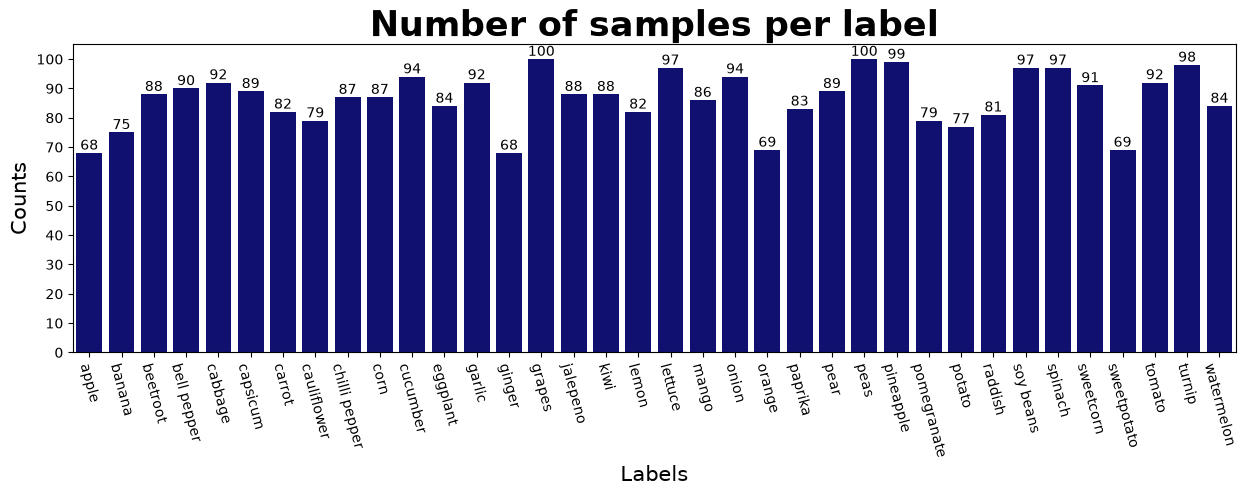

In [39]:
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
count = []
for cls in classes:
    count.append(len(os.listdir(os.path.join(train_dir, cls))))

plt.figure(figsize=(15, 4))
ax = sns.barplot(x=classes, y=count, color='navy')
plt.xticks(rotation=285)
for i in ax.containers:
    ax.bar_label(i)
plt.title('Number of samples per label', fontsize=25, fontweight='bold')
plt.xlabel('Labels', fontsize=15)
plt.ylabel('Counts', fontsize=15)
plt.yticks(np.arange(0, 105, 10))
plt.show()

In [40]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.2, 0.2),
        scale=(0.9, 1.1),
        shear=0.1
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [41]:
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [42]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=validation_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_test_transforms)

In [63]:
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [65]:
base_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

In [66]:
for param in base_model.parameters():
    param.requires_grad = False

In [67]:
unfreeze_start_name = 'features.16'
unfreeze = False
for name, param in base_model.named_parameters():
    if unfreeze_start_name in name:
        unfreeze = True
    if unfreeze:
        param.requires_grad = True

In [ ]:
class FruitVegetableClassifier(nn.Module):
    def __init__(self, base_model, num_classes=36):
        super().__init__()
        self.features = base_model.features
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),  
            nn.Linear(1280, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)      
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

In [69]:
model = FruitVegetableClassifier(base_model, num_classes=len(train_dataset.classes))
model = model.to(device)

In [70]:
def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    total = trainable + non_trainable
    print(f"Total parameters: {total:,}")
    print(f"Trainable parameters: {trainable:,}")
    print(f"Non-trainable parameters: {non_trainable:,}")

print("\n--- Model summary ---")
count_parameters(model)


--- Model summary ---
Total parameters: 2,589,348
Trainable parameters: 1,571,556
Non-trainable parameters: 1,017,792


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

In [72]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_model = None
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                if self.restore_best_weights and self.best_model is not None:
                    model.load_state_dict(self.best_model)
                return True
            return False

early_stopping = EarlyStopping(patience=10, restore_best_weights=True)
best_model_wts = None
best_val_loss = float('inf')

In [73]:
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

In [ ]:
num_epochs = 100
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct / total

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'best_model.pth'))
    
    if epoch % 10 == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f'model_epoch_{epoch}.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': epoch_val_loss,
            'val_acc': epoch_val_acc,
        }, checkpoint_path)
        print(f"Checkpoint salvato: {checkpoint_path}")

    scheduler.step(epoch_val_loss)

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    current_lr = optimizer.param_groups[0]['lr']
    history['lr'].append(current_lr)

    print(f"Epoch {epoch}/{num_epochs} "
          f"train_loss: {epoch_train_loss:.4f} - train_acc: {epoch_train_acc:.4f} "
          f"val_loss: {epoch_val_loss:.4f} - val_acc: {epoch_val_acc:.4f} - lr: {current_lr:.6f}")

    if early_stopping(epoch_val_loss, model):
        print("Early stopping triggered")
        break

if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    print("Miglior modello caricato con val_loss:", best_val_loss)

c:\Users\Io Tu\Desktop\Boh\.venv2\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/100 train_loss: 3.2152 - train_acc: 0.2295 val_loss: 1.6771 - val_acc: 0.5470 - lr: 0.001000
Epoch 2/100 train_loss: 1.8067 - train_acc: 0.5978 val_loss: 0.7311 - val_acc: 0.7436 - lr: 0.001000
Epoch 3/100 train_loss: 1.0066 - train_acc: 0.7034 val_loss: 0.5164 - val_acc: 0.8091 - lr: 0.001000
Epoch 4/100 train_loss: 0.7160 - train_acc: 0.7714 val_loss: 0.3884 - val_acc: 0.8689 - lr: 0.001000
Epoch 5/100 train_loss: 0.5888 - train_acc: 0.8125 val_loss: 0.3898 - val_acc: 0.8632 - lr: 0.001000
Epoch 6/100 train_loss: 0.5316 - train_acc: 0.8305 val_loss: 0.3256 - val_acc: 0.9088 - lr: 0.001000
Epoch 7/100 train_loss: 0.4723 - train_acc: 0.8385 val_loss: 0.2816 - val_acc: 0.9031 - lr: 0.001000
Epoch 8/100 train_loss: 0.4160 - train_acc: 0.8543 val_loss: 0.3568 - val_acc: 0.8832 - lr: 0.001000
Epoch 9/100 train_loss: 0.4400 - train_acc: 0.8469 val_loss: 0.3205 - val_acc: 0.8746 - lr: 0.001000
Checkpoint salvato: checkpoints\model_epoch_10.pth
Epoch 10/100 train_loss: 0.3488 - train_

    train_loss  train_acc  val_loss   val_acc        lr
41    0.067936   0.976886  0.175694  0.957265  0.000063
42    0.064406   0.978491  0.178042  0.948718  0.000063
43    0.065534   0.979133  0.176967  0.954416  0.000031
44    0.062067   0.978812  0.179699  0.954416  0.000031
45    0.057730   0.981380  0.182813  0.951567  0.000031


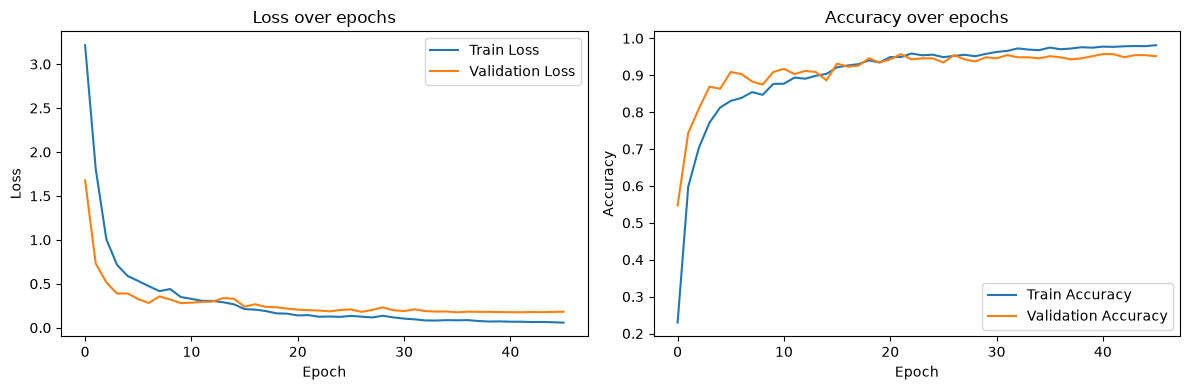

In [ ]:
history_df = pd.DataFrame(history)
print(history_df.tail())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_df['train_loss'], label='Train Loss')
ax1.plot(history_df['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Loss over epochs')

ax2.plot(history_df['train_acc'], label='Train Accuracy')
ax2.plot(history_df['val_acc'], label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.set_title('Accuracy over epochs')
plt.tight_layout()
plt.show()

In [76]:
model.eval()
y_true = []
y_pred = []
test_loss = 0.0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_accuracy = correct / total
test_loss_avg = test_loss / len(test_dataset)
print(f"Test Loss: {test_loss_avg:.4f}, Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1710, Test Accuracy: 0.9526


In [ ]:
import os

labels_path = 'labels2.txt'
with open(labels_path, 'w') as f:
    for cls in train_dataset.classes:
        f.write(f"{cls}\n")
        
print(f"Salvato con successo {labels_path} con {len(train_dataset.classes)} etichette.")

Salvato con successo labels2.txt con 36 etichette.


In [ ]:
import torch

model.eval()
model.to('cpu')

original_model_path = 'modello_originale.pth'
torch.save(model.state_dict(), original_model_path)

print(f"Modello PyTorch originale salvato in: {original_model_path}")

Modello PyTorch originale salvato in: modello_originale.pth


In [79]:
from torch.utils.mobile_optimizer import optimize_for_mobile

example_input = torch.rand(1, 3, 224, 224)
traced_script_module = torch.jit.trace(model, example_input)
optimized_traced_model = optimize_for_mobile(traced_script_module)

android_model_path = "modello_android.ptl"
optimized_traced_model._save_for_lite_interpreter(android_model_path)

print(f"Modello ottimizzato per Android salvato in: {android_model_path}")

Modello ottimizzato per Android salvato in: modello_android.ptl


C:\Users\Io Tu\AppData\Local\Temp\ipykernel_7820\1829071745.py:8: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_traced_model._save_for_lite_interpreter(android_model_path)
